# EDA Phase 5: User-Level Longitudinal Analysis

**Project:** CycleInsight  
**Dataset:** `datasets/cleaned_dataset.csv`  
**Unit of analysis:** Participant (`id`). Day-level observations are summarized within each participant before between-participant comparisons.  
**Scope:** Descriptive analysis only. This notebook does not fit machine-learning or predictive models and makes no causal or medical claims.


## Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


## Configuration

In [5]:
# Resolve project paths whether the notebook is launched from the project root or notebooks folder.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "datasets" / "cleaned_dataset.csv"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

USER_COL = "id"
DAY_COL = "day_in_study"
PHASE_COL = "phase"
SYMPTOM_COLS = [
    "headaches", "cramps", "sorebreasts", "fatigue", "sleepissue",
    "moodswing", "stress", "foodcravings", "indigestion", "bloating",
]
PHASE_ORDER = ["Menstrual", "Follicular", "Fertility", "Luteal"]
ABSENT_RESPONSES = {"not at all", "none", "no", "0"}

sns.set_theme(style="whitegrid", context="notebook")


## Data Loading

In [7]:
# Load the day-level source once; subsequent analysis builds one summary row per participant.
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} daily records from {df[USER_COL].nunique():,} participants.")
df.head()


Loaded 2,937 daily records from 42 participants.


,id,age,study_interval,day_in_study,phase,medications,bleeding_days,lh,estrogen,flow intensity,...,BBT_std_7d,heavy_bleeding_flag_proxy,anovulation_proxy,HMB_label,synthetic_augmented_flag,advice_text,advice_type,advice_source,advice_confidence,validator_flag
0,1,23,2022,1,Follicular,Panadol,0,2.9,94.2,Not at all,...,0.082042,2.16,1,0.43,1,Follicular phase tip: it's a great time for hi...,monitoring,synthetic_augmented,0.69,0
1,1,23,2022,2,Follicular,Panadol,0,1.2,226.3,Not at all,...,0.027300,2.01,1,0.72,1,Follicular phase tip: it's a great time for hi...,monitoring,synthetic_augmented,0.69,0
2,1,23,2022,3,Follicular,Panadol,0,3.5,276.8,Not at all,...,0.028271,2.58,1,0.24,1,Follicular phase tip: it's a great time for hi...,monitoring,synthetic_augmented,0.69,0
3,1,23,2022,4,Fertility,Not at all,0,1.8,322.1,Not at all,...,0.068841,1.36,0,0.23,1,"If phase isn't clear, keep tracking symptoms —...",monitoring,synthetic_augmented,0.63,0
4,1,23,2022,5,Fertility,Not at all,0,4.6,244.9,Not at all,...,0.069268,2.67,0,0.36,1,"If phase isn't clear, keep tracking symptoms —...",monitoring,synthetic_augmented,0.63,0


## Helper Functions

In [12]:
def summarize_numeric_by_user(data, column):
    """Return participant-level mean and standard deviation for a numeric field."""
    return data.groupby(USER_COL)[column].agg(["mean", "std"]).rename(
        columns={"mean": f"{column}_mean", "std": f"{column}_std"}
    )


def plot_and_save(fig, filename):
    """Save a finished figure in the shared reports/figures directory."""
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


## 1. User Coverage

,records,observed_days,first_study_day,last_study_day,study_day_span,coverage_percent_of_span
count,42.0,42.0,42.0,42.0,42.0,42.0
mean,69.9,69.9,1.1,84.5,84.4,82.2
std,19.2,19.2,0.3,13.0,13.1,16.6
min,11.0,11.0,1.0,15.0,14.0,47.7
25%,57.2,57.2,1.0,86.0,86.0,70.8
50%,77.0,77.0,1.0,89.0,89.0,86.0
75%,85.8,85.8,1.0,89.0,89.0,96.3
max,89.0,89.0,2.0,90.0,90.0,100.0


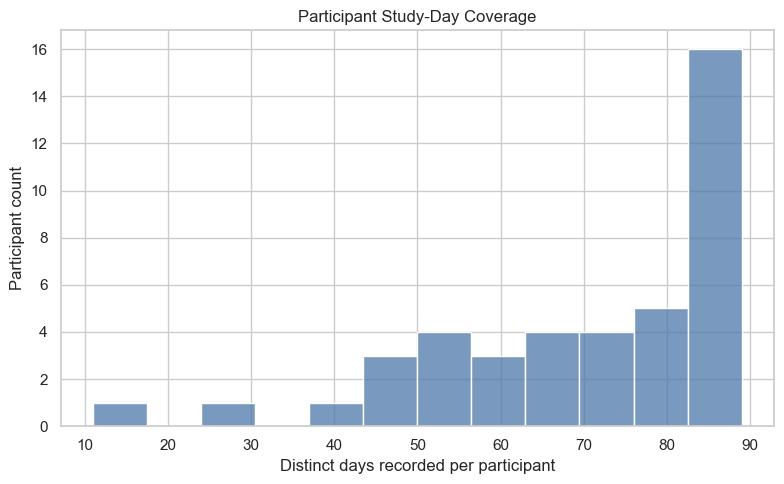

In [15]:
# Coverage describes how many distinct study days each participant contributed.
user_coverage = df.groupby(USER_COL).agg(
    records=(DAY_COL, "size"),
    observed_days=(DAY_COL, "nunique"),
    first_study_day=(DAY_COL, "min"),
    last_study_day=(DAY_COL, "max"),
)
user_coverage["study_day_span"] = user_coverage["last_study_day"] - user_coverage["first_study_day"] + 1
user_coverage["coverage_percent_of_span"] = (
    100 * user_coverage["observed_days"] / user_coverage["study_day_span"]
)

display(user_coverage.describe().round(1))
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(user_coverage["observed_days"], bins=12, color="#4C78A8", ax=ax)
ax.set(title="Participant Study-Day Coverage", xlabel="Distinct days recorded per participant", ylabel="Participant count")
plot_and_save(fig, "eda5_user_coverage.png")


## 2. User Symptom Burden

,mean_burden,median_burden,burden_sd,records_with_burden
count,42.00,42.00,42.00,42.00
mean,6.96,6.79,1.34,69.93
std,2.85,3.30,1.13,19.21
min,1.29,0.00,0.00,11.00
25%,5.03,5.00,0.27,57.25
50%,7.52,7.50,1.33,77.00
75%,9.92,10.00,1.75,85.75
max,10.00,10.00,4.50,89.00


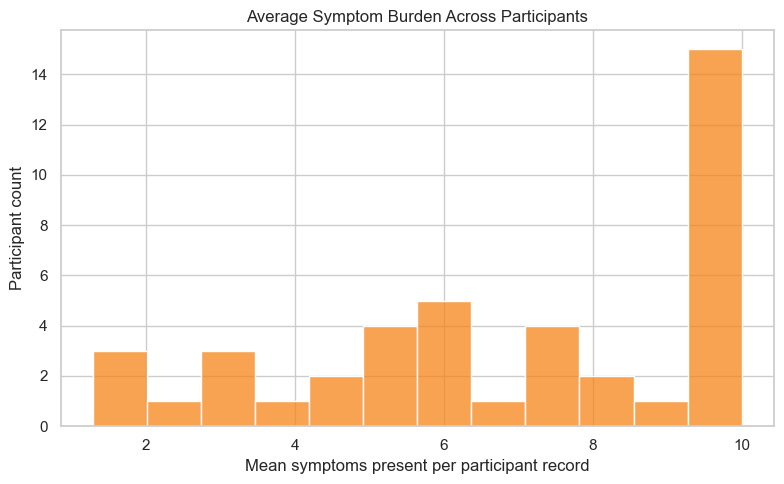

In [17]:
# Convert symptom intensity labels to presence, then summarize mean burden within participant.
required = [USER_COL, DAY_COL, PHASE_COL, *SYMPTOM_COLS]
missing_columns = [column for column in required if column not in df.columns]
if missing_columns:
    raise ValueError(f"Required columns are missing: {missing_columns}")

symptom_flags = pd.DataFrame(index=df.index)
for column in SYMPTOM_COLS:
    response = df[column].astype("string").str.strip().str.lower()
    symptom_flags[column] = np.where(
        response.isna(), np.nan, (~response.isin(ABSENT_RESPONSES)).astype(float)
    )

day_level = df[[USER_COL, DAY_COL, PHASE_COL]].copy()
day_level[SYMPTOM_COLS] = symptom_flags
day_level["symptom_burden"] = symptom_flags.sum(axis=1, min_count=1)

user_burden = day_level.groupby(USER_COL).agg(
    mean_burden=("symptom_burden", "mean"),
    median_burden=("symptom_burden", "median"),
    burden_sd=("symptom_burden", "std"),
    records_with_burden=("symptom_burden", "count"),
)
display(user_burden.describe().round(2))

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(user_burden["mean_burden"], bins=12, color="#F58518", ax=ax)
ax.set(title="Average Symptom Burden Across Participants", xlabel="Mean symptoms present per participant record", ylabel="Participant count")
plot_and_save(fig, "eda5_user_mean_symptom_burden.png")


## 3. User Cycle Characteristics

,inter_cycle_length_mean,inter_cycle_length_std,cycle_variability_mean,cycle_variability_std,bleeding_days_mean,bleeding_days_std
count,42.00,42.0,42.00,42.00,42.00,42.00
mean,24.95,0.0,3.03,1.15,1.07,2.09
std,2.61,0.0,0.16,0.08,0.71,0.78
min,21.00,0.0,2.58,0.98,0.16,0.65
25%,22.25,0.0,2.94,1.10,0.55,1.43
50%,25.50,0.0,3.06,1.15,0.95,2.08
75%,27.00,0.0,3.13,1.20,1.49,2.61
max,28.00,0.0,3.34,1.43,4.50,4.97


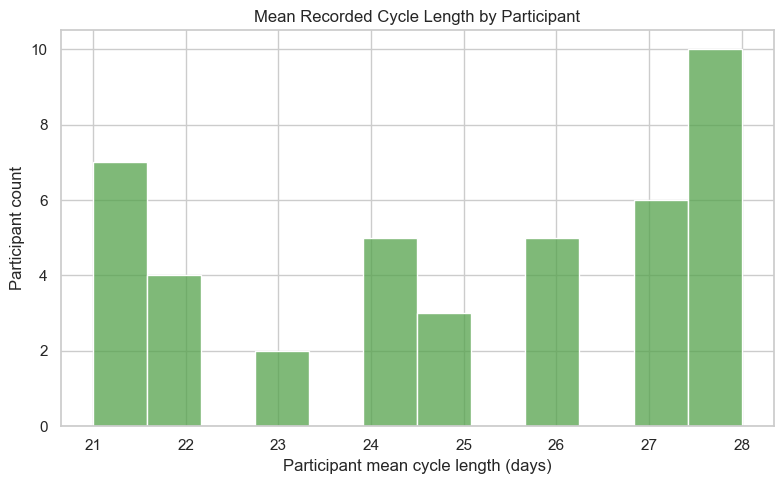

In [20]:
# Summarize each participant's recorded cycle measures rather than pooling daily values.
cycle_fields = [column for column in ["inter_cycle_length", "cycle_variability", "bleeding_days"] if column in df.columns]
user_cycle = pd.DataFrame(index=user_coverage.index)
for column in cycle_fields:
    user_cycle = user_cycle.join(summarize_numeric_by_user(df, column), how="left")

display(user_cycle.describe().round(2))
if "inter_cycle_length_mean" in user_cycle.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.histplot(user_cycle["inter_cycle_length_mean"], bins=12, color="#54A24B", ax=ax)
    ax.set(title="Mean Recorded Cycle Length by Participant", xlabel="Participant mean cycle length (days)", ylabel="Participant count")
    plot_and_save(fig, "eda5_user_cycle_length.png")


## 4. User Phase Distribution

phase,Menstrual,Follicular,Fertility,Luteal
count,42.0,42.0,42.0,42.0
mean,19.8,25.9,21.9,32.3
std,7.6,11.2,6.2,10.5
min,6.3,7.3,9.1,0.0
25%,14.5,19.3,18.1,27.3
50%,18.9,24.9,22.9,33.1
75%,23.5,30.8,24.3,38.7
max,50.0,63.6,42.3,52.9


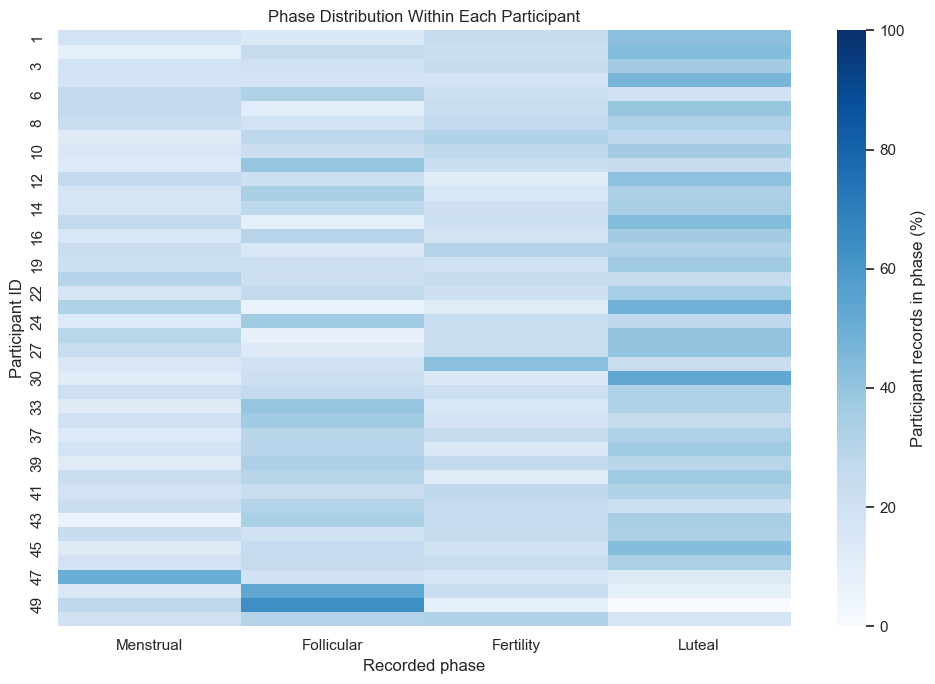

In [23]:
# Compare phase composition for each participant using within-participant percentages.
user_phase_counts = pd.crosstab(day_level[USER_COL], day_level[PHASE_COL]).reindex(columns=PHASE_ORDER, fill_value=0)
user_phase_percent = user_phase_counts.div(user_phase_counts.sum(axis=1), axis=0).mul(100)

display(user_phase_percent.describe().round(1))
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(user_phase_percent, cmap="Blues", vmin=0, vmax=100,
            cbar_kws={"label": "Participant records in phase (%)"}, ax=ax)
ax.set(title="Phase Distribution Within Each Participant", xlabel="Recorded phase", ylabel="Participant ID")
plot_and_save(fig, "eda5_user_phase_distribution.png")


## 5. User Profiles

In [26]:
# Assemble one descriptive profile per participant from within-user averages and prevalences.
user_profiles = user_coverage[["observed_days", "coverage_percent_of_span"]].join(user_burden["mean_burden"])
user_profiles = user_profiles.join(user_cycle)
for field in ["age", "BMI"]:
    if field in df.columns:
        user_profiles[field] = df.groupby(USER_COL)[field].first()
if "sleep_hours" in df.columns:
    user_profiles["mean_sleep_hours"] = df.groupby(USER_COL)["sleep_hours"].mean()

user_symptom_prevalence = day_level.groupby(USER_COL)[SYMPTOM_COLS].mean().mul(100)
user_profiles = user_profiles.join(user_symptom_prevalence.add_suffix("_prevalence_pct"))
user_profiles = user_profiles.join(user_phase_percent)

# Display a readable subset; the complete participant table remains available as user_profiles.
profile_columns = [column for column in ["observed_days", "mean_burden", "inter_cycle_length_mean", "age", "BMI", "mean_sleep_hours"] if column in user_profiles]
display(user_profiles[profile_columns].describe().round(2))
display(user_profiles.sort_values("mean_burden", ascending=False).head(10).round(2))


,observed_days,mean_burden,inter_cycle_length_mean,age,BMI,mean_sleep_hours
count,42.00,42.00,42.00,42.00,42.00,42.00
mean,69.93,6.96,24.95,20.88,23.56,7.19
std,19.21,2.85,2.61,2.72,4.69,0.11
min,11.00,1.29,21.00,18.00,16.88,6.97
25%,57.25,5.03,22.25,19.00,19.95,7.11
50%,77.00,7.52,25.50,20.00,22.46,7.20
75%,85.75,9.92,27.00,22.75,25.63,7.24
max,89.00,10.00,28.00,29.00,35.84,7.47


,observed_days,coverage_percent_of_span,mean_burden,inter_cycle_length_mean,inter_cycle_length_std,cycle_variability_mean,cycle_variability_std,bleeding_days_mean,bleeding_days_std,age,...,sleepissue_prevalence_pct,moodswing_prevalence_pct,stress_prevalence_pct,foodcravings_prevalence_pct,indigestion_prevalence_pct,bloating_prevalence_pct,Menstrual,Follicular,Fertility,Luteal
id,,,,,,,,,,,,,,,,,,,,,
1,74,83.15,10.00,28.0,0.0,2.78,1.16,0.88,1.91,23,...,100.0,100.0,100.0,100.00,100.0,100.00,18.92,14.86,24.32,41.89
9,86,96.63,10.00,21.0,0.0,3.01,1.13,0.52,1.43,18,...,100.0,100.0,100.0,100.00,100.0,100.00,12.79,27.91,31.40,27.91
29,26,50.00,10.00,28.0,0.0,3.06,1.43,0.46,1.45,24,...,100.0,100.0,100.0,100.00,100.0,100.00,15.38,19.23,42.31,23.08
16,50,58.14,10.00,27.0,0.0,2.58,1.14,0.68,1.62,23,...,100.0,100.0,100.0,100.00,100.0,100.00,16.00,30.00,18.00,36.00
27,80,89.89,10.00,22.0,0.0,3.02,1.24,1.51,2.74,25,...,100.0,100.0,100.0,100.00,100.0,100.00,23.75,12.50,23.75,40.00
12,70,81.40,10.00,22.0,0.0,3.13,1.17,1.54,2.64,23,...,100.0,100.0,100.0,100.00,100.0,100.00,25.71,21.43,11.43,41.43
47,52,66.67,10.00,23.0,0.0,2.97,0.98,4.50,4.97,20,...,100.0,100.0,100.0,100.00,100.0,100.00,50.00,19.23,17.31,13.46
10,75,83.33,9.99,25.0,0.0,3.21,1.16,0.55,1.34,20,...,100.0,100.0,100.0,100.00,100.0,98.67,14.67,22.67,26.67,36.00
22,57,76.00,9.98,28.0,0.0,3.03,1.08,0.91,2.04,20,...,100.0,100.0,100.0,100.00,100.0,100.00,17.54,26.32,21.05,35.09


## 6. User Similarity Exploration

id,1,2,3,4,6
id,,,,,
1,1.00,0.47,0.30,0.41,0.88
2,0.47,1.00,0.72,0.82,0.46
3,0.30,0.72,1.00,0.75,0.33
4,0.41,0.82,0.75,1.00,0.32
6,0.88,0.46,0.33,0.32,1.00


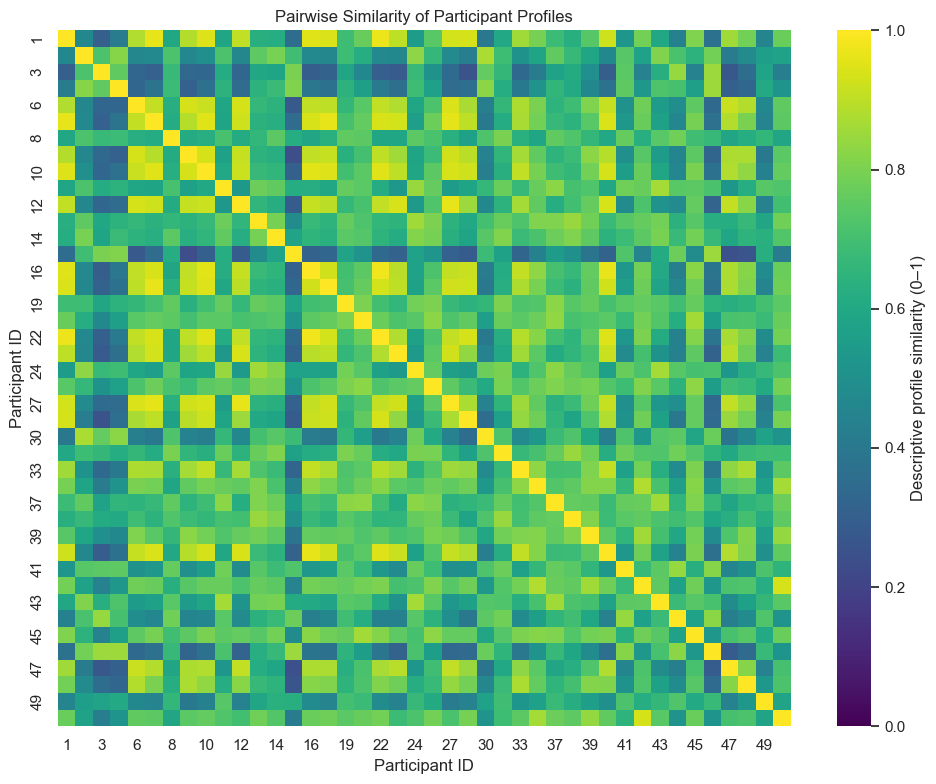

In [28]:
# Compare participant profiles on a common 0-1 scale; this is descriptive, not clustering or prediction.
similarity_features = ["mean_burden"]
similarity_features += [f"{column}_prevalence_pct" for column in SYMPTOM_COLS]
if "inter_cycle_length_mean" in user_profiles.columns:
    similarity_features.append("inter_cycle_length_mean")
similarity_features += list(PHASE_ORDER)

similarity_data = user_profiles[similarity_features].copy()
similarity_data = similarity_data.loc[:, similarity_data.nunique(dropna=True) > 1]
# Normalize each feature by its observed range so units do not dominate the comparison.
feature_min = similarity_data.min()
feature_range = similarity_data.max() - feature_min
scaled_profiles = (similarity_data - feature_min) / feature_range.replace(0, np.nan)
scaled_profiles = scaled_profiles.fillna(0)

# Similarity is one minus mean absolute feature distance; values closer to 1 indicate closer profiles.
profile_distance = pd.DataFrame(index=scaled_profiles.index, columns=scaled_profiles.index, dtype=float)
for participant_a in scaled_profiles.index:
    differences = scaled_profiles.subtract(scaled_profiles.loc[participant_a]).abs()
    profile_distance.loc[participant_a] = differences.mean(axis=1)
profile_similarity = 1 - profile_distance

display(profile_similarity.iloc[:5, :5].round(2))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(profile_similarity, cmap="viridis", vmin=0, vmax=1,
            cbar_kws={"label": "Descriptive profile similarity (0–1)"}, ax=ax)
ax.set(title="Pairwise Similarity of Participant Profiles", xlabel="Participant ID", ylabel="Participant ID")
plot_and_save(fig, "eda5_user_profile_similarity.png")


## 7. Findings

### Key Findings

- The dataset contains **42 participants** with a median of **77 recorded days** each (range: **11–89**). Coverage differs noticeably between participants, so pooled record-level counts would give greater weight to participants with more observations.
- Participant mean symptom burden has a median of **7.52 symptoms per observed record** and ranges from **1.29 to 10.00**. Participant-level variation is substantial.
- Mean recorded cycle length across participants is approximately **25 days** (participant means range from **21 to 28 days** in this dataset).
- Phase representation is not identical for all participants. The phase heatmap shows the within-participant percentage mix and can highlight sparse or uneven coverage.
- The similarity heatmap compares normalized descriptive profiles using average absolute feature distance. It is exploratory and does not assign participant types.

### Data Quality Notes

- The source contains repeated day-level rows per participant; all comparisons in this notebook use participant summaries or within-participant percentages.
- Symptom presence is defined as a non-missing response other than “Not at all” (also accepting `none`, `no`, and `0` as absent). Missing responses are excluded from symptom prevalence denominators and burden counts.
- `inter_cycle_length` and `cycle_variability` are summarized as recorded; confirm their construction and units before treating the within-participant statistics as independently observed cycle measurements.
- Participant profile similarity depends on the selected features and min-max scaling used here. It is a descriptive comparison only.

### Recommended Next Step

Review participant coverage and phase balance before later analyses, then compare results with equal-weight participant summaries wherever day-level pooling is used.
